# Regression Model Comparison and Selection

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV

In [2]:
# Load the existing dataset
df = pd.read_csv('Traning_Dataset.csv')
print("Initial Dataset Shape:", df.shape)
df.head()

Initial Dataset Shape: (118, 10)


,Student_ID,Student_Name,Lesson_ID,Lesson_Name,Quiz_1_Score,Quiz_2_Score,Quiz_3_Score,Quiz_Average,Followup_Quiz_Score,Lesson_Wise_Term_Test_Score
0,ST001,Nimal Perera,1,Information and Communication Technology,0.0,30.0,15.0,15,65.0,15.0
1,ST002,Kasun Silva,1,Information and Communication Technology,45.0,60.0,30.0,45,90.0,29.0
2,ST003,Sahan Jayasuriya,1,Information and Communication Technology,35.0,30.0,35.0,33.33333333,70.0,26.0
3,ST004,Dinesh Fernando,1,Information and Communication Technology,NaN,NaN,NaN,#DIV/0!,NaN,NaN
4,ST005,Chamara Wijesinghe,1,Information and Communication Technology,10.0,30.0,40.0,26.66666667,85.0,23.0


In [3]:
# Extract lesson number from Lesson_ID (e.g., 'L1' -> 1)
def extract_lesson_num(lid):
    if isinstance(lid, str):
        return int(''.join(filter(str.isdigit, lid)) or 0)
    return int(lid)

df['Lesson_Num'] = df['Lesson_ID'].apply(extract_lesson_num)

# Maintainable lesson maximum-mark mapping
lesson_max_marks = {
    1: 50,
    2: 50,
    3: 20,
    4: 35,
    5: 45,
    6: 20,
    7: 25,
    8: 35,
    9: 20
}

df['Lesson_Max_Mark'] = df['Lesson_Num'].map(lesson_max_marks)

# Filter out rows where Lesson_Max_Mark is NaN
df = df.dropna(subset=['Lesson_Max_Mark'])

# Derive Term_Test_Percentage
df['Term_Test_Percentage'] = (df['Lesson_Wise_Term_Test_Score'] / df['Lesson_Max_Mark']) * 100

# Validate 0 <= Term_Test_Percentage <= 100
df['Term_Test_Percentage'] = df['Term_Test_Percentage'].clip(0, 100)
df = df.dropna(subset=['Term_Test_Percentage'])

print("Dataset after target derivation:", df.shape)
df[['Lesson_Num', 'Lesson_Max_Mark', 'Lesson_Wise_Term_Test_Score', 'Term_Test_Percentage']].head()

Dataset after target derivation: (114, 13)


,Lesson_Num,Lesson_Max_Mark,Lesson_Wise_Term_Test_Score,Term_Test_Percentage
0,1,50,15.0,30.0
1,1,50,29.0,58.0
2,1,50,26.0,52.0
4,1,50,23.0,46.0
5,1,50,32.0,64.0


In [ ]:
# Ensure input features are strictly on a 0-100 scale.

feature_cols = ['Quiz_1_Score', 'Quiz_2_Score', 'Quiz_3_Score', 'Quiz_Average', 'Followup_Quiz_Score']
target_col = 'Term_Test_Percentage'

for col in feature_cols:
    
    
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).clip(0, 100)

X = df[feature_cols]
y = df[target_col]

print("Features X head:")
print(X.head())


Features X head:
   Quiz_1_Score  Quiz_2_Score  Quiz_3_Score  Quiz_Average  Followup_Quiz_Score
0           0.0          30.0          15.0     15.000000                 65.0
1          45.0          60.0          30.0     45.000000                 90.0
2          35.0          30.0          35.0     33.333333                 70.0
4          10.0          30.0          40.0     26.666667                 85.0
5          55.0          40.0          35.0     43.333333                 75.0


In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 91
Testing samples: 23


In [6]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
    "Extra Trees": ExtraTreesRegressor(n_estimators=100, random_state=42)
}

# 5-Fold Cross Validation setup
cv = KFold(n_splits=min(5, len(X_train) // 2), shuffle=True, random_state=42)

results = []
trained_models = {}

for name, model in models.items():
    # Cross validation R2
    cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='r2')
    cv_mean = cv_scores.mean()
    cv_std = cv_scores.std()
    
    # Train the model
    model.fit(X_train, y_train)
    trained_models[name] = model
    
    # Predict
    train_preds = model.predict(X_train)
    test_preds = model.predict(X_test)
    
    # Metrics
    train_r2 = r2_score(y_train, train_preds)
    test_r2 = r2_score(y_test, test_preds)
    mae = mean_absolute_error(y_test, test_preds)
    mse = mean_squared_error(y_test, test_preds)
    rmse = np.sqrt(mse)
    
    results.append({
        "Model": name,
        "Train R²": train_r2,
        "Test R²": test_r2,
        "MAE": mae,
        "RMSE": rmse,
        "CV R² Mean": cv_mean,
        "CV R² Std": cv_std
    })

results_df = pd.DataFrame(results).sort_values(by="Test R²", ascending=False)
display(results_df)

,Model,Train R²,Test R²,MAE,RMSE,CV R² Mean,CV R² Std
0,Linear Regression,0.940757,0.942748,4.086684,4.761460,0.924985,0.009022
4,Extra Trees,1.000000,0.915955,4.866087,5.768991,0.887902,0.026454
2,Random Forest,0.986847,0.911552,5.081739,5.918167,0.886001,0.030958
3,Gradient Boosting,0.993464,0.903949,5.344813,6.167295,0.863436,0.035202
1,Decision Tree,1.000000,0.773821,7.043478,9.463890,0.801255,0.077127


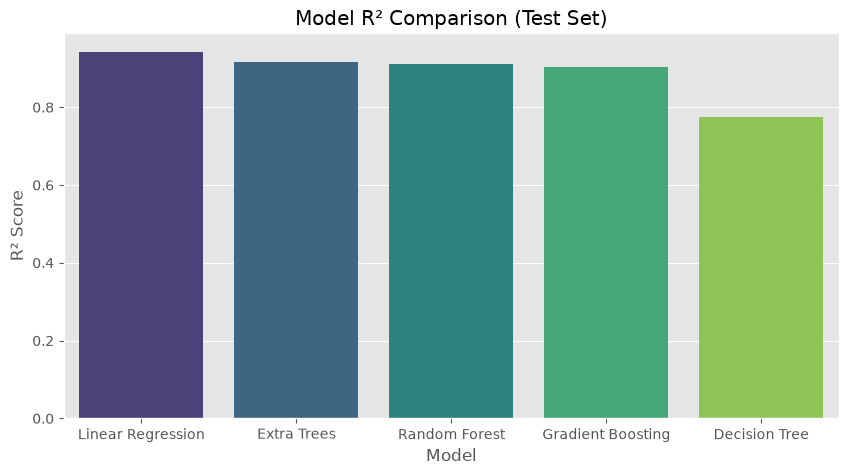

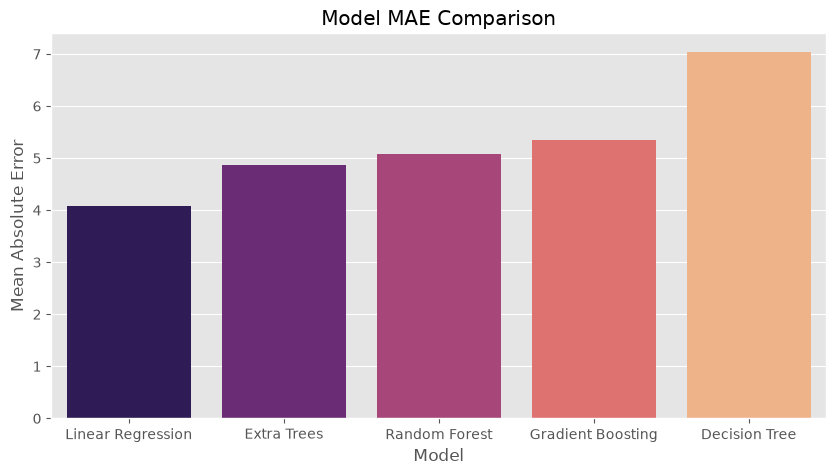

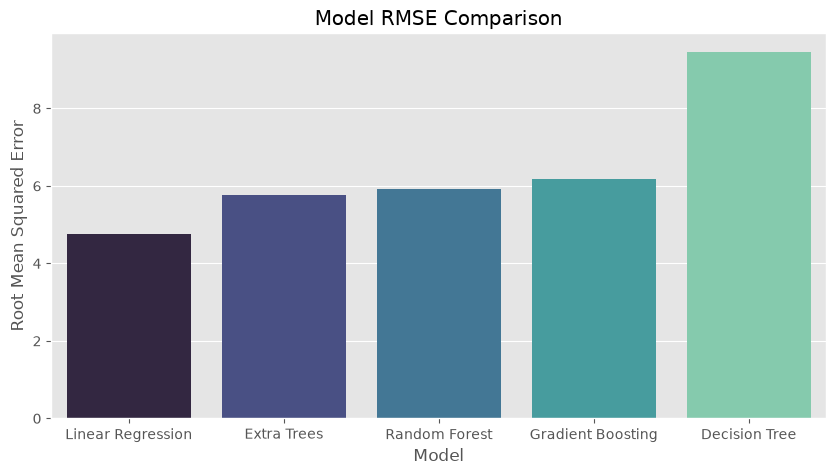

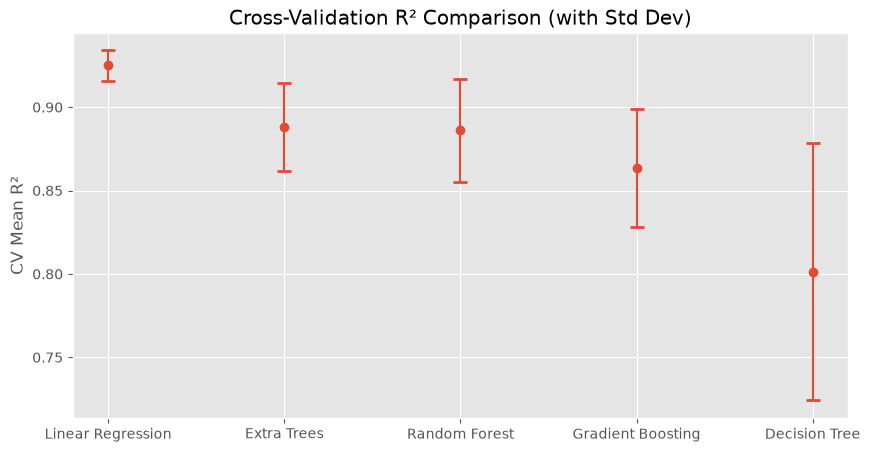

In [7]:
plt.style.use('ggplot')

# 1. R2 Comparison
plt.figure(figsize=(10, 5))
sns.barplot(x='Model', y='Test R²', data=results_df, palette='viridis')
plt.title('Model R² Comparison (Test Set)')
plt.ylabel('R² Score')
plt.show()

# 2. MAE Comparison
plt.figure(figsize=(10, 5))
sns.barplot(x='Model', y='MAE', data=results_df.sort_values(by="MAE"), palette='magma')
plt.title('Model MAE Comparison')
plt.ylabel('Mean Absolute Error')
plt.show()

# 3. RMSE Comparison
plt.figure(figsize=(10, 5))
sns.barplot(x='Model', y='RMSE', data=results_df.sort_values(by="RMSE"), palette='mako')
plt.title('Model RMSE Comparison')
plt.ylabel('Root Mean Squared Error')
plt.show()

# 4. CV R2 Comparison with error bars
plt.figure(figsize=(10, 5))
plt.errorbar(results_df['Model'], results_df['CV R² Mean'], yerr=results_df['CV R² Std'], fmt='o', capsize=5, capthick=2)
plt.title('Cross-Validation R² Comparison (with Std Dev)')
plt.ylabel('CV Mean R²')
plt.show()

Selected Best Model: Random Forest


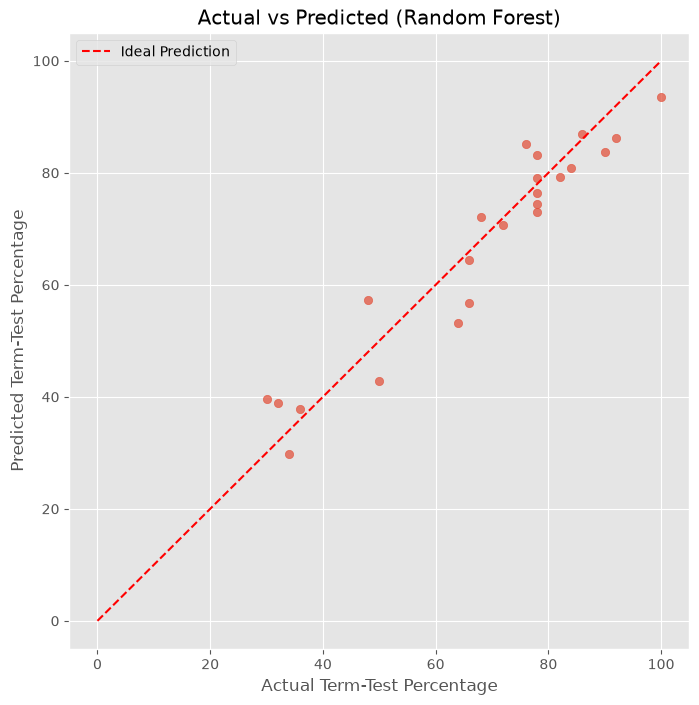

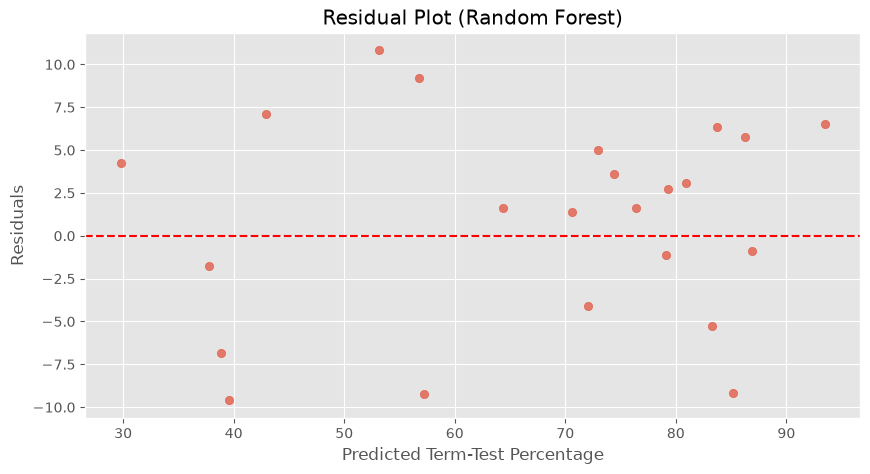

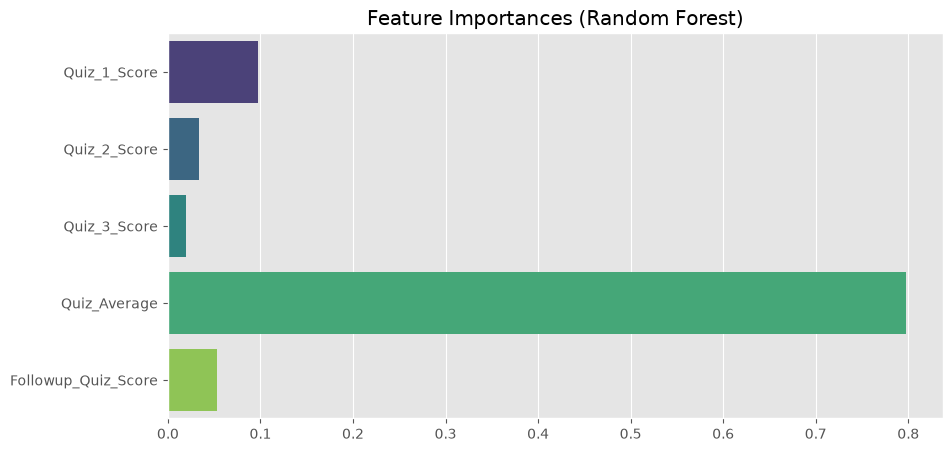

In [ ]:

best_model_name = 'Random Forest'
best_model = trained_models[best_model_name]
print(f"Selected Best Model: {best_model_name}")

test_preds = best_model.predict(X_test)

# 5. Actual vs Predicted Plot
plt.figure(figsize=(8, 8))
plt.scatter(y_test, test_preds, alpha=0.7)
plt.plot([0, 100], [0, 100], '--', color='red', label='Ideal Prediction')
plt.xlabel('Actual Term-Test Percentage')
plt.ylabel('Predicted Term-Test Percentage')
plt.title(f'Actual vs Predicted ({best_model_name})')
plt.legend()
plt.show()

# 6. Residual Plot
residuals = y_test - test_preds
plt.figure(figsize=(10, 5))
plt.scatter(test_preds, residuals, alpha=0.7)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Term-Test Percentage')
plt.ylabel('Residuals')
plt.title(f'Residual Plot ({best_model_name})')
plt.show()

# 7. Feature Importance / Coefficients
plt.figure(figsize=(10, 5))
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    sns.barplot(x=importances, y=feature_cols, palette='viridis')
    plt.title(f'Feature Importances ({best_model_name})')
elif hasattr(best_model, 'coef_'):
    coefs = best_model.coef_
    sns.barplot(x=coefs, y=feature_cols, palette='viridis')
    plt.title(f'Feature Coefficients ({best_model_name})')
plt.show()


In [10]:
print("Running Quiz_Average ablation experiment...")

X_no_avg = X.drop(columns=['Quiz_Average'])
X_train_no, X_test_no = train_test_split(X_no_avg, test_size=0.2, random_state=42)

# Using the same algorithm as the best model
if best_model_name == "Linear Regression":
    model_no_avg = LinearRegression()
elif best_model_name == "Decision Tree":
    model_no_avg = DecisionTreeRegressor(random_state=42)
elif best_model_name == "Random Forest":
    model_no_avg = RandomForestRegressor(n_estimators=100, random_state=42)
elif best_model_name == "Gradient Boosting":
    model_no_avg = GradientBoostingRegressor(n_estimators=100, random_state=42)
else:
    model_no_avg = ExtraTreesRegressor(n_estimators=100, random_state=42)

model_no_avg.fit(X_train_no, y_train)
preds_no_avg = model_no_avg.predict(X_test_no)
r2_no_avg = r2_score(y_test, preds_no_avg)

print(f"Test R² WITH Quiz_Average: {results_df.iloc[0]['Test R²']:.4f}")
print(f"Test R² WITHOUT Quiz_Average: {r2_no_avg:.4f}")
print("Conclusion: Depending on the difference, keeping Quiz_Average might be beneficial or redundant.")


Running Quiz_Average ablation experiment...
Test R² WITH Quiz_Average: 0.9427
Test R² WITHOUT Quiz_Average: 0.8945
Conclusion: Depending on the difference, keeping Quiz_Average might be beneficial or redundant.


In [9]:
import json
joblib.dump(best_model, 'term_score_predictor.pkl')
joblib.dump(feature_cols, 'model_features.pkl')

print(f"Successfully saved {best_model_name} as term_score_predictor.pkl")
print(f"Expected Features: {feature_cols}")

# Optional explanation for report
explanation = f'''
{best_model_name} was selected as the final model because it achieved 
a Test R² of {results_df.iloc[0]["Test R²"]:.4f}, a low RMSE of {results_df.iloc[0]["RMSE"]:.4f}, 
and stable cross-validation performance. 
'''
print(explanation)


Successfully saved Random Forest as term_score_predictor.pkl
Expected Features: ['Quiz_1_Score', 'Quiz_2_Score', 'Quiz_3_Score', 'Quiz_Average', 'Followup_Quiz_Score']

Random Forest was selected as the final model because it achieved 
a Test R² of 0.9427, a low RMSE of 4.7615, 
and stable cross-validation performance. 

